# scPipe-Multimodal Seurat

In [ ]:
# if (!requireNamespace("BiocManager", quietly = TRUE)) install.packages("BiocManager")
# BiocManager::install(c("harmony"))
# BiocManager::install(c("glmGamPoi"))
# BiocManager::install('limma')

# install.packages("Seurat")
# install.packages("sctransform")

# install.packages('devtools')
# devtools::install_github('immunogenomics/presto')

In [1]:
# Library import

library(Seurat)
library(ggplot2)
library(sctransform)
library(harmony)
library(patchwork)
library(dplyr)
library(magrittr)
library(purrr)

set.seed(14)

# Multicore CPU usage activation - Future

library(future)

# plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

# options(future.globals.maxSize = 48000 * 1024^2) # Mac Pros have 64 Gb
options(future.globals.maxSize = 16000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed=TRUE # Removes future-generated statistical errors

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Rcpp


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘purrr’


The following object is masked from ‘package:magrittr’:

    set_names




# Pre-processing

In [ ]:
# Import

# Helper: check whether a directory contains 10x-style files
is_10x_dir <- function(p) {                                              # Define a small helper that returns TRUE if 'p' looks like a 10x folder.
  files <- tolower(list.files(p))                                         # List files in 'p' and lowercase names for robust matching.
  has_flat <- all(c("matrix.mtx.gz","features.tsv.gz","barcodes.tsv.gz") # Detect the “flat” 10x layout: 3 standard files in the folder.
                     %in% files)
  has_sub  <- dir.exists(file.path(p, "filtered_feature_bc_matrix"))      # Detect the common subfolder layout from Cell Ranger outputs.
  has_flat || has_sub                                                     # Return TRUE if either layout is present.
}

# Minimal importer: RNA (+ADT/HTO if present) with automatic annotation 
load_citeseq <- function(data_dir = "Data") {                       # Main function; expects root folder 'Data'.
  stopifnot(dir.exists(data_dir))                                         # Fail early if the root directory does not exist.

  group_dirs  <- list.dirs(data_dir, full.names = TRUE, recursive = FALSE) # Enumerate top-level folders; each is a biological group.
  if (!length(group_dirs))                                                # If no group folders are found,
    stop("No group folders found inside: ", data_dir)                     # throw an informative error.

  sample_dirs <- map(group_dirs, ~                                        # For each group folder,
    list.dirs(.x, full.names = TRUE, recursive = FALSE)) |>
    unlist(use.names = FALSE)                                             # collect immediate subfolders (each should be a sample).
  sample_dirs <- sample_dirs[vapply(sample_dirs, is_10x_dir, logical(1))]# Keep only those sample folders that look like valid 10x dirs.
  if (!length(sample_dirs))                                               # If none remain,
    stop("No sample folders with 10x files found.")                       # error out.

  message("Found samples: ", length(sample_dirs))                         # Inform how many samples will be loaded.

  objs <- map(sample_dirs, function(sdir) {                               # Iterate over sample directories and build a Seurat object per sample.
    group  <- basename(dirname(sdir))                                     # Derive the group label from the parent directory name.
    sample <- basename(sdir)                                              # Derive the sample label from the directory name.
    ident  <- paste(group, sample, sep = "_")                            # Compose a unique identifier 'group_sample'.

    tenx_path <- if (dir.exists(file.path(sdir, "filtered_feature_bc_matrix"))) {
      file.path(sdir, "filtered_feature_bc_matrix")                       # Prefer the subfolder if it exists (standard Cell Ranger output).
    } else sdir                                                           # Otherwise, use the sample directory itself (flat layout).

    counts <- Read10X(tenx_path)                                          # Read matrices; returns a matrix OR a named list of matrices.

    if (is.list(counts)) {                                                # If multiple modalities are present (feature barcoding),
      rna <- counts[["Gene Expression"]]                                  # pull the RNA matrix by conventional key.
      adt <- counts[["Antibody Capture"]]                                 # pull the ADT (antibody) matrix if available.
      hto <- counts[["Multiplexing Capture"]]                             # pull the HTO (hashtag) matrix if available.
      if (is.null(rna) && length(counts) == 1L) {                         # Edge case: a single unnamed/other slot — treat as RNA.
        rna <- counts[[1]]
      }
    } else {
      rna <- counts                                                       # If only one matrix was returned, treat it as RNA.
      adt <- NULL                                                         # No ADT in this sample.
      hto <- NULL                                                         # No HTO in this sample.
    }
    if (is.null(rna))                                                     # If RNA still not found,
      stop("Sample ", ident, " is missing 'Gene Expression' counts.")     # produce a clear error (protect downstream steps).

    so <- CreateSeuratObject(counts = rna, project = ident)               # Create a Seurat object from the RNA counts; minimal defaults.

    if (!is.null(adt))                                                    # If ADT (antibody capture) data exists,
      so[["ADT"]] <- CreateAssayObject(counts = adt)                      # attach it as a separate assay named "ADT".
    if (!is.null(hto))                                                    # If HTO (hashtag) data exists,
      so[["HTO"]] <- CreateAssayObject(counts = hto)                      # attach it as a separate assay named "HTO".

    so$Group        <- group                                              # Annotate per-cell metadata: biological group label.
    so$Sample       <- sample                                             # Annotate per-cell metadata: sample label.
    so$Batch        <- ident                                              # Annotate per-cell metadata: combined batch label.
    so$orig.ident   <- ident                                              # Conventional Seurat field for original identity.
    Idents(so)      <- "group"                                            # Set the active identity to group (useful for quick tables/plots).

    so <- RenameCells(so, new.names = paste0(ident, "_", colnames(so)))   # Make cell names globally unique by prefixing group_sample.
    so                                                                     # Return the per-sample Seurat object to the map() call.
  })

  obj <- Reduce(function(x, y) merge(x, y), objs)                         # Merge all sample-level Seurat objects into one combined object.
  message("Done. Assays present: ", paste(Assays(obj), collapse = ", "))  # Report which assays (RNA/ADT/HTO) are present.
  return(obj)                                                             # Return the combined annotated Seurat object (no processing applied).
}

In [ ]:
merged_seurat <- load_citeseq("Data")             # Load and annotate from Data/<group>/<sample>/… directory tree.
table(merged_seurat$Group, merged_seurat$Sample)  # Quick sanity check: counts of cells per group × sample.
Assays(merged_seurat)                             # Verify modalities present (e.g., "RNA", "ADT", "HTO").

In [ ]:
head(merged_seurat@meta.data)

In [ ]:
Idents(merged_seurat) <- "Batch"
merged_seurat

In [ ]:
# FeatureScatter Plot QC

# plot_QC_1 <- FeatureScatter(merged_seurat, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot_QC_2 <- FeatureScatter(merged_seurat, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
# plot_QC_1
plot_QC_2

In [ ]:
merged_seurat_QC <- subset(merged_seurat, subset = 
                           nFeature_RNA > 35 
                           # & nFeature_RNA < 7500
                           # & percent.mt < 23.5
                          )
# plot_QC_1 <- FeatureScatter(merged_seurat_QC, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot_QC_2 <- FeatureScatter(merged_seurat_QC, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
# plot_QC_1
plot_QC_2

merged_seurat_QC

In [ ]:
# Контроль качества при помощи FeatureScatter Plot

p1 <- FeatureScatter(merged_seurat_QC, feature2 = "nCount_ADT", feature1 = "nFeature_ADT")
p1

In [ ]:
merged_seurat_QC_ADT <- subset(merged_seurat_QC,  nCount_ADT < 24000 & nFeature_ADT > 10)

p2 <- FeatureScatter(merged_seurat_QC_ADT, feature2 = "nCount_ADT", feature1 = "nFeature_ADT")
p2
merged_seurat_QC_ADT

In [ ]:
merged_seurat <- merged_seurat_QC_ADT

In [ ]:
SCT_merged_seurat <- SCTransform(merged_seurat, method = "glmGamPoi", verbose = TRUE)

In [ ]:
rename_features <- function(obj, rename_adt = TRUE, rename_hto = TRUE) {

  .rename_assay_rows <- function(assay_obj, prefix, split_first = c(":", "-")) {
    old <- rownames(assay_obj)
    if (!length(old)) return(assay_obj)

    base <- old
    if (any(grepl(split_first[1], base))) {
      base <- sub(paste0(split_first[1], ".*$"), "", base)
    } else if (any(grepl(split_first[2], base))) {
      base <- sub(paste0(split_first[2], ".*$"), "", base)
    }
    new <- make.unique(paste0(prefix, base))
    key <- setNames(new, old)

    if (!is.null(assay_obj@counts))                        rownames(assay_obj@counts)        <- unname(key[rownames(assay_obj@counts)])
    if (!is.null(assay_obj@data))                          rownames(assay_obj@data)          <- unname(key[rownames(assay_obj@data)])
    if (!is.null(assay_obj@scale.data) && nrow(assay_obj@scale.data) > 0)
                                                           rownames(assay_obj@scale.data)    <- unname(key[rownames(assay_obj@scale.data)])
    if (!is.null(assay_obj@meta.features) && nrow(assay_obj@meta.features) > 0)
                                                           rownames(assay_obj@meta.features) <- unname(key[rownames(assay_obj@meta.features)])
    assay_obj
  }

  # ADT
  if (rename_adt && "ADT" %in% Assays(obj)) {
    obj[["ADT"]] <- .rename_assay_rows(obj[["ADT"]], prefix = "Protein-")
    message("ADT features renamed with prefix 'Protein-'.")
  }

  # HTO
  if (rename_hto && "HTO" %in% Assays(obj)) {
    obj[["HTO"]] <- .rename_assay_rows(obj[["HTO"]], prefix = "HTO-")
    message("HTO features renamed with prefix 'HTO-'.")
  }
  obj
}

In [ ]:
SCT_merged_seurat <- rename_features(SCT_merged_seurat, rename_adt = TRUE, rename_hto = FALSE)
rownames(SCT_merged_seurat[["ADT"]])

In [ ]:
# AbSeq Norm
DefaultAssay(SCT_merged_seurat) <- 'ADT'

VariableFeatures(SCT_merged_seurat) <- rownames(SCT_merged_seurat[["ADT"]])
SCT_merged_seurat <- NormalizeData(SCT_merged_seurat, normalization.method = 'CLR', margin = 2) %>% 
  ScaleData() %>% RunPCA(reduction.name = 'apca')

In [ ]:
# Calculate PCs using variable features determined by SCTransform
SCT_merged_seurat <- RunPCA(SCT_merged_seurat, assay = "SCT", npcs = 40)

In [ ]:
harmonized_seurat <- RunHarmony(SCT_merged_seurat, 
#                                 group.by.vars = c("Sample"),
                                group.by.vars = c("Group"),
                                reduction = "pca", assay.use = "SCT", plot_convergence = FALSE, 
                                project.dim = F, reduction.save = "mRNA_harmony")

In [ ]:
harmonized_seurat <- RunHarmony(harmonized_seurat, 
                                group.by.vars = c("Group"), 
#                                 group.by.vars = c("Sample"),
                                reduction = "apca", assay.use = "ADT", plot_convergence = FALSE, 
                                project.dim = F, reduction.save = "abseq_harmony")

In [ ]:
ElbowPlot(harmonized_seurat, ndims = 40, reduction = "mRNA_harmony")

In [ ]:
ElbowPlot(harmonized_seurat, ndims = 30, reduction = "abseq_harmony")

In [ ]:
# WNN multimodal integration
harmonized_seurat <- FindMultiModalNeighbors(
  harmonized_seurat, reduction.list = list("mRNA_harmony", "abseq_harmony"), 
  dims.list = list(1:28, 1:6), modality.weight.name = "RNA.weight"
)
harmonized_seurat <- RunUMAP(harmonized_seurat, nn.name = "weighted.nn", 
                             reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")

In [ ]:
by <- "Batch"
split_idx <- split(colnames(harmonized_seurat), harmonized_seurat[[by]][,1])

# target per-batch count
target <- floor(30000 / length(split_idx))

keep <- unlist(lapply(split_idx, function(v) {
  if (length(v) <= target) v else sample(v, target)
}), use.names = FALSE)

# if total < 20k (small batches), top up proportionally from remaining
if (length(keep) < 20000) {
  remaining <- setdiff(colnames(harmonized_seurat), keep)
  keep <- c(keep, sample(remaining, min(20000 - length(keep), length(remaining))))
}

plot_obj <- subset(harmonized_seurat, cells = keep)

DimPlot(
  plot_obj,
  reduction = "wnn.umap",
  group.by  = "Batch",
  label     = FALSE,
  pt.size   = 0.25,
  label.size= 10
)

ggsave(
  "Harmony.png",
  plot   = last_plot(),
  width  = 22.5,
  height = 15,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
DefaultAssay(harmonized_seurat) <- 'ADT'
features_Ab = rownames(harmonized_seurat[["ADT"]])

FeaturePlot(plot_obj, features = features_Ab, 
                  reduction = 'wnn.umap', ncol = 5)

ggsave(
  "PEX.png",
  plot   = last_plot(),
  width  = 55,
  height = 30,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
DefaultAssay(harmonized_seurat) <- 'SCT'

genes_panel <- c(
  # Naive (CD4/CD8)
  "CCR7","IL7R","SELL",
  # CD8 memory / TRM-like
  "GZMK","KLRK1","NKG7",
  # Cytotoxic CD8 effector
  "GZMB","GNLY","PRF1","CCL3","CCL4",
  # Tfh-like CD4 memory
  "CXCR5","PDCD1","IL21","BCL6",
  # Th17-like CD4 memory/activated
  "RORC","CCR6","IL23R",
  # Treg
  "FOXP3","IKZF2","CTLA4","IL2RA",
  # NK / innate / γδ
  "KLRC1","ZBTB16","CXCL8",
  # TCR chains
  "TRAC","TRBC1","TRBC2","TRGC","TRDC"
)

FeaturePlot(harmonized_seurat, features = genes_panel, 
                  reduction = 'wnn.umap', ncol = 5)

ggsave(
  "GEX.png",
  plot   = last_plot(),
  width  = 55,
  height = 60,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
# harmonized_seurat <- readRDS("Seurat_Clusters.rds")

In [ ]:
harmonized_seurat <- FindClusters(harmonized_seurat, graph.name = "wsnn", algorithm = 3, 
                                  resolution = 0.36, verbose = FALSE)
# Seurat Clusters
DimPlot(harmonized_seurat, 
              reduction = "wnn.umap",
              group.by = "seurat_clusters",
              label = TRUE, pt.size = 0.5, 
              label.size = 5, repel = TRUE)

ggsave( 
  "Clusters.png",
  plot   = last_plot(),
  width  = 17,
  height = 15,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
harmonized_seurat <- PrepSCTFindMarkers(harmonized_seurat)

In [ ]:
# If your current Idents are clusters, merge 11, 12, 3
cur <- as.character(Idents(harmonized_seurat))
harmonized_seurat$cluster_merged <- factor(ifelse(cur %in% c("11","12","3"), "3", cur))
Idents(harmonized_seurat) <- "cluster_merged"

In [ ]:
# RNA markers on SCT (no extra normalization needed) 
DefaultAssay(harmonized_seurat) <- "SCT"

# sanity check (should be > 0 rows)
stopifnot(nrow(harmonized_seurat[["SCT"]]@data) > 0)

markers_rna <- FindAllMarkers(
  harmonized_seurat,
  only.pos        = TRUE,
  min.pct         = 0.10,
  logfc.threshold = 0.25,
  test.use        = "wilcox"
)

# harmonize column for ranking
if (!"avg_log2FC" %in% colnames(markers_rna) && "avg_logFC" %in% colnames(markers_rna)) {
  markers_rna$avg_log2FC <- markers_rna$avg_logFC
}
top50_rna <- markers_rna %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC), .by_group = TRUE) %>%
  slice_head(n = 50) %>%
  ungroup()

# ADT markers (CLR-normalize if needed) 
if (!"ADT" %in% Assays(harmonized_seurat)) stop("No ADT assay found.")
DefaultAssay(harmonized_seurat) <- "ADT"
if (is.null(harmonized_seurat[["ADT"]]@data) || nrow(harmonized_seurat[["ADT"]]@data) == 0) {
  harmonized_seurat <- NormalizeData(harmonized_seurat, assay = "ADT", normalization.method = "CLR", margin = 2, verbose = FALSE)
}

markers_adt <- FindAllMarkers(
  harmonized_seurat,
  only.pos        = TRUE,
  min.pct         = 0.05,
  logfc.threshold = 0,
  test.use        = "wilcox"
)

# Save 
write.csv(top50_rna, "markers_RNA_top50_per_cluster.csv", row.names = FALSE)
write.csv(markers_adt, "markers_ADT_all.csv", row.names = FALSE)

In [ ]:
# Seurat Clusters
DimPlot(harmonized_seurat, 
              reduction = "wnn.umap",
              label = TRUE, pt.size = 0.5, 
              label.size = 5, repel = TRUE)

CD8 lineage

8 – CD8_TN (naive): strong CCR7/TCF7/LEF1/IL7R/SELL, minimal cytotoxic genes

2 – CD8_TCM: retains CCR7/SELL/IL7R, little GZMB/GNLY/PRF1 (central-memory profile)

6 – CD8_TEM/TRM: GZMK, NKG7, KLRK1 up; weaker CCR7/SELL (effector-memory/TRM-like)

5 – CD8_Teff: clear GZMB, GNLY, PRF1, CCL3/4 peaks (cytotoxic effector)

CD4 lineage

10 – CD4_TN (naive): CCR7/TCF7/LEF1/IL7R/SELL high

1 – CD4_TCM (early): TCF7/IL7R present; CXCR5 faint (central-memory; not fully Tfh)

3 – CD4_Tfh: enrichment of CXCR5, PDCD1, IL21, BCL6 (modest but localized) (Tfh-like)

4 – CD4_Th17-like: focal RORC, CCR6, IL23R (Th17/Th17-primed)

0 – Treg: crisp FOXP3, IKZF2, CTLA4, IL2RA island (Treg)

Innate-like / unconventional

9 – γδ / innate-like T: TRDC stripe with KLRC1/ZBTB16 support

7 – NKT

In [ ]:
levels(harmonized_seurat) <- c('8','2','6','5',
                               '10','1','3','4','0',
                               '9',
                               '7'
                              )

new.cluster.ids <- c('CD8 Naïve','CD8 CM', 'CD8 TEM', 'CD8 Teff',
                     'CD4 Naïve','CD4 CM', 'CD4 FH', 'CD4 Th17', 'CD4 Treg',
                     'γδ',
                     'NKT'
                     )

names(new.cluster.ids) <- levels(harmonized_seurat)
harmonized_seurat <- RenameIdents(harmonized_seurat, new.cluster.ids)

In [ ]:
# Seurat Clusters
DimPlot(harmonized_seurat, 
              reduction = "wnn.umap",
              label = TRUE, pt.size = 0.5, 
              label.size = 4, repel = TRUE)

ggsave( 
  "Clusters.png",
  plot   = last_plot(),
  width  = 20,
  height = 18,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
saveRDS(harmonized_seurat, file = "Seurat_Clusters.rds")

In [ ]:
head(harmonized_seurat@meta.data)

In [ ]:
harmonized_seurat$CellType <- Idents(harmonized_seurat)

In [ ]:
table(harmonized_seurat@meta.data$CellType)

# Main Analysis

In [2]:
harmonized_seurat <- readRDS("Seurat_Clusters.rds")

In [3]:
# SCT_seurat_object@meta.data
harmonized_seurat$CellType <- Idents(harmonized_seurat)

In [4]:
if (!requireNamespace("ggalluvial", quietly = TRUE)) install.packages("ggalluvial")
if (!requireNamespace("dplyr", quietly = TRUE)) install.packages("dplyr")
if (!requireNamespace("showtext", quietly = TRUE)) install.packages("showtext")

library(dplyr)
library(ggplot2)
library(ggalluvial)
library(showtext)

Loading required package: sysfonts

Loading required package: showtextdb



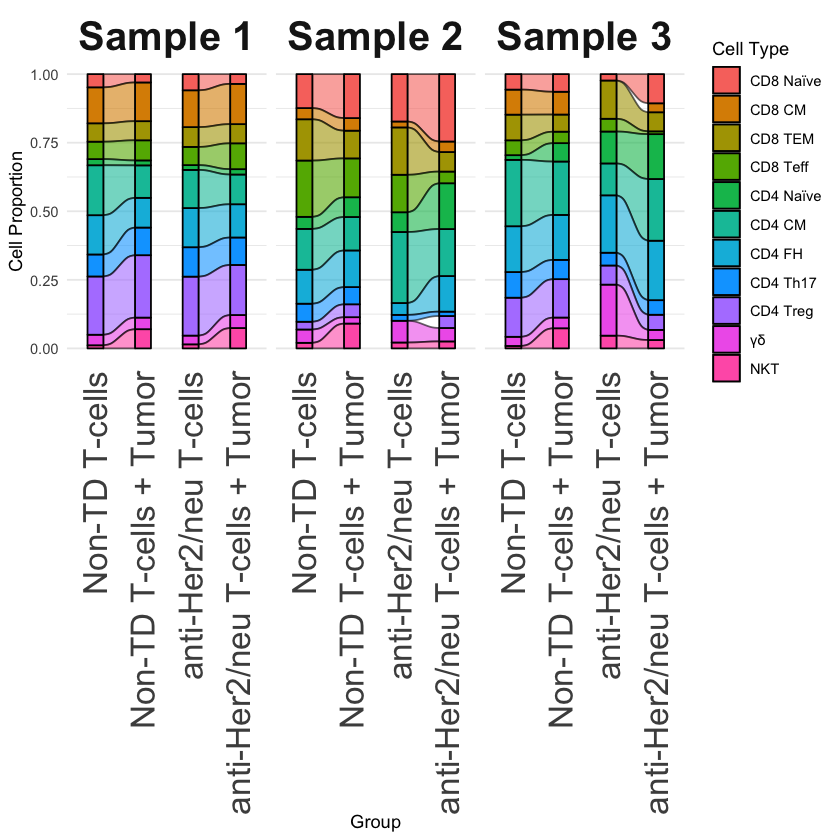

In [36]:
plot_data <- harmonized_seurat@meta.data %>%
  mutate(Group = gsub("anti-Her2:neu", "anti-Her2/neu", Group)) %>%
  mutate(Treatment_Set = ifelse(grepl("Non-TD", Group), "Set1", "Set2")) %>%
  mutate(Alluvium_ID = paste(CellType, Treatment_Set, sep = "_")) %>%

  group_by(Sample, Group, CellType, Alluvium_ID) %>%
  summarise(Count = n(), .groups = "drop") %>%
  group_by(Sample, Group) %>%
  mutate(Proportion = Count / sum(Count)) %>%

  mutate(Group = factor(Group, levels = c(
    "Non-TD T-cells", 
    "Non-TD T-cells + Tumor", 
    "anti-Her2/neu T-cells", 
    "anti-Her2/neu T-cells + Tumor"
  )))

ggplot(plot_data, aes(x = Group, y = Proportion, alluvium = Alluvium_ID, stratum = CellType, fill = CellType)) +
  geom_flow(alpha = 0.6, color = "black") +
  geom_stratum(alpha = 1, color = "black") +
  facet_wrap(~Sample) +  
  theme_minimal() +
  labs(x = "Group", y = "Cell Proportion", fill = "Cell Type") +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 20),
    strip.text = element_text(size = 24, face = "bold"),
    legend.position = "right",
    panel.grid.major.x = element_blank()
  )

ggsave(
  "Alluvial_per_sample_broken_rivers.png",
  plot   = last_plot(),
  width  = 40,
  height = 31,
  units  = "cm",
  dpi    = 600,
  bg     = "white"
)

In [ ]:
# Cluster per group
ggplot(harmonized_seurat@meta.data, aes(x=Group, fill=CellType)) + geom_bar(position = "fill")

ggsave( 
  "Cluster per group.png",
  plot   = last_plot(),
  width  = 20,
  height = 50,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
genes_panel <- c(
  "CCR7","IL7R","SELL",
  "CD8A",
  'CD4',"FOXP3","TRDC"
)

activated_nkt_panel <- c(
    'TLR2','EGR3',"CXCL8",'LIF',
    'HLA-DQA1','HLA-DQB1','HLA-DRA','HLA-DRB3','HLA-DMA','HLA-DMB','HLA-DPA1','HLA-DPB1','LGALS1','LGALS3')

t_cell_checkpoints <- c(
  "PDCD1",     # PD-1
  "CTLA4",     # CTLA-4
  "LAG3",      # LAG-3
  "HAVCR2",    # TIM-3
  "TIGIT",     # TIGIT
  "BTLA",      # BTLA
  "PVRIG",     # PVRIG
  "CD96",      # CD96
  "KLRG1",     # KLRG1
  "LAIR1",     # LAIR-1
  "C10orf54",      # VISTA / C10orf54 (rename to VISTA)
  "ADORA2A",   # A2A adenosine receptor
  "ENTPD1",    # CD39 (ecto-ATPase)
  "NT5E",      # CD73 (ecto-5'-nucleotidase)
  "CD160",     # CD160 (часто ингибитор через HVEM)
  "SIGLEC7",   # иногда на T, глико-ингибитор
  "SIGLEC9",
  "KLRB1",      # CD161, чаще ингибитор на CD8 T
  "CD28",      # CD28
  "ICOS",      # ICOS
  "CD27",      # CD27
  "TNFRSF9",   # 4-1BB
  "TNFRSF18",  # GITR
  "TNFRSF4",   # OX40
  "CD226",     # DNAM-1 (антагонизм с TIGIT)
  "SLAMF6",    # Ly108
    'IL2RA','CD69',
  "GZMA","GZMB","GNLY","PRF1","IFNG","TNF",'FASLG'
)

In [ ]:
# Idents(harmonized_seurat) <- "CellType"

# library(viridis)

# # DefaultAssay(harmonized_seurat) <- 'SCT'
# # DotPlot(harmonized_seurat, 
# #         features = genes_panel) + RotatedAxis() + coord_flip() + scale_colour_gradient2(low = "blue", mid = "white", high = "red") 
# # # + theme(axis.text.x = element_text(angle = 90))

# # ggsave( 
# #   "Dot Plot GEX.png",
# #   plot   = last_plot(),
# #   width  = 40, 
# #   height = 20,
# #   units  = "cm",
# #   dpi    = 600,
# #   limitsize = TRUE,
# #   bg     = "white"
# # )

# DefaultAssay(harmonized_seurat) <- 'ADT'
# DotPlot(harmonized_seurat, 
#         features = rownames(harmonized_seurat[["ADT"]])) + RotatedAxis() + coord_flip()  + scale_colour_gradient2(low = "blue", mid = "white", high = "red") 
# # + theme(axis.text.x = element_text(angle = 90))

# ggsave( 
#   "Dot Plot PEX.png",
#   plot   = last_plot(),
#   width  = 30, 
#   height = 20,
#   units  = "cm",
#   dpi    = 600,
#   limitsize = TRUE,
#   bg     = "white"
# )

In [ ]:
# Split by biogroup

stopifnot(all(c("CellType","Group") %in% colnames(harmonized_seurat@meta.data)))

harmonized_seurat$CellType_Group <- paste(harmonized_seurat$CellType,
                                          harmonized_seurat$Group, sep = "_")

combo <- unique(harmonized_seurat@meta.data[, c("CellType","Group","CellType_Group")])
combo <- combo[order(combo$CellType, combo$Group), , drop = FALSE]
ordered_levels <- combo$CellType_Group

harmonized_seurat$CellType_Group <- factor(harmonized_seurat$CellType_Group,
                                           levels = ordered_levels)

In [ ]:
Idents(harmonized_seurat) <- "CellType_Group"

library(viridis)

DefaultAssay(harmonized_seurat) <- 'SCT'
# DotPlot(harmonized_seurat, 
#         features = genes_panel) + RotatedAxis() + coord_flip() + scale_colour_gradient2(low = "blue", mid = "white", high = "red")  + theme(axis.text.x = element_text(angle = 90))

# ggsave( 
#   "Dot Plot GEX Groups.png",
#   plot   = last_plot(),
#   width  = 55, 
#   height = 20,
#   units  = "cm",
#   dpi    = 600,
#   limitsize = TRUE,
#   bg     = "white"
# )

DotPlot(harmonized_seurat, 
        features = t_cell_checkpoints) + RotatedAxis() + coord_flip() + scale_colour_gradient2(low = "blue", mid = "white", high = "red")  + theme(axis.text.x = element_text(angle = 90))

ggsave( 
  "Dot Plot Tsign Groups.png",
  plot   = last_plot(),
  width  = 55, 
  height = 30 ,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

DotPlot(harmonized_seurat, 
        features = activated_nkt_panel) + RotatedAxis() + coord_flip() + scale_colour_gradient2(low = "blue", mid = "white", high = "red")  + theme(axis.text.x = element_text(angle = 90))

ggsave( 
  "Dot Plot aNKT Groups.png",
  plot   = last_plot(),
  width  = 55, 
  height = 25,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

DefaultAssay(harmonized_seurat) <- 'ADT'
DotPlot(harmonized_seurat, 
        features = c('Protein-CCR7',"sct_CCR7",'Protein-CD127',"sct_IL7R",'Protein-CD62L',"sct_SELL",
                     'Protein-CD8',"sct_CD8A",'Protein-CD4','sct_CD4','Protein-CD25',"sct_FOXP3",'Protein-CD294',
                     'Protein-CD45RA','Protein-CD45RO', 'Protein-CD86','Protein-CD95',
                     'Protein-CD117','Protein-CD122',"sct_TRDC",
                     'Protein-CD56','Protein-CD71')
                    ) + RotatedAxis() + coord_flip()  + scale_colour_gradient2(low = "blue", mid = "white", high = "red")  + theme(axis.text.x = element_text(angle = 90))

ggsave( 
  "Dot Plot MEX Groups.png",
  plot   = last_plot(),
  width  = 55, 
  height = 35,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [ ]:
install.packages("writexl") # if needed
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(writexl)
  library(rlang)
})

cell_percentages_to_excel <- function(
  seu,
  celltype_col = "CellType",
  sample_col   = "Batch",
  outfile      = "cell_percentages_by_sample.xlsx",
  digits       = 2,
  include_na   = FALSE
) {
  md <- seu@meta.data
  if (!all(c(celltype_col, sample_col) %in% colnames(md))) {
    stop("Columns not found in meta.data: ",
         paste(setdiff(c(celltype_col, sample_col), colnames(md)), collapse = ", "))
  }

  df <- md %>%
    select(!!sym(sample_col), !!sym(celltype_col))

  if (!include_na) {
    df <- df %>% filter(!is.na(.data[[sample_col]]), !is.na(.data[[celltype_col]]))
  }

  # totals per sample
  totals <- df %>%
    count(!!sym(sample_col), name = "total_cells") %>%
    arrange(.data[[sample_col]])

  # counts per (sample, celltype)
  counts_long <- df %>%
    count(!!sym(sample_col), !!sym(celltype_col), name = "n") %>%
    arrange(.data[[sample_col]], .data[[celltype_col]])

  # add percentages
  perc_long <- counts_long %>%
    left_join(totals, by = sample_col) %>%
    mutate(percent = round(100 * n / total_cells, digits)) %>%
    arrange(.data[[sample_col]], desc(percent), .data[[celltype_col]])

  # wide tables
  counts_wide <- counts_long %>%
    pivot_wider(names_from = !!sym(celltype_col), values_from = n, values_fill = 0) %>%
    arrange(.data[[sample_col]])

  perc_wide <- perc_long %>%
    select(!!sym(sample_col), !!sym(celltype_col), percent) %>%
    pivot_wider(names_from = !!sym(celltype_col), values_from = percent, values_fill = 0) %>%
    arrange(.data[[sample_col]])

  # save to Excel (multiple sheets)
  write_xlsx(
    list(
      sample_totals = totals,
      counts_long   = counts_long,
      perc_long     = perc_long,
      counts_wide   = counts_wide,
      perc_wide     = perc_wide
    ),
    path = outfile
  )

  message("Saved: ", normalizePath(outfile))
  invisible(list(
    totals = totals,
    counts_long = counts_long,
    perc_long = perc_long,
    counts_wide = counts_wide,
    perc_wide = perc_wide
  ))
}

In [ ]:
# Example with your object/columns
res <- cell_percentages_to_excel(
  harmonized_seurat,
  celltype_col = "CellType",
  sample_col   = "Batch",
  outfile      = "cell_percentages_by_sample.xlsx"
)

# DME

In [ ]:
"CD8 Teff", "CD4 CM", "γδ", "NKT"

In [ ]:
# DGE

Idents(harmonized_seurat) <- "CellType_Group"
DefaultAssay(harmonized_seurat) <- 'SCT'
# DefaultAssay(harmonized_seurat) <- 'ADT'

DME <- FindMarkers(harmonized_seurat, ident.1 = "CD8 Teff_Non-TD T-cells + Tumor", ident.2 = "CD8 Teff_Non-TD T-cells",
             logfc.threshold = 1, test.use = "wilcox")

DME %>% 
  dplyr::filter(p_val_adj < 0.05) %>% 
  dplyr::arrange(desc(avg_log2FC)) %>% 
  tibble::rownames_to_column("gene") %>% 
  readr::write_csv("CD8 Teff_CD4 CM Non-TD.csv")

DME